In [222]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [223]:
from sklearn.tree import DecisionTreeClassifier
import graphviz
from sklearn.metrics import classification_report, accuracy_score, r2_score, mean_absolute_error
from sklearn import tree
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = DecisionTreeClassifier(max_features='sqrt').fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

train accuracy= 100.000%
test accuracy= 93.706%


'Source.gv.pdf'

In [224]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = RandomForestClassifier(n_estimators= 100).fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


In [225]:
from sklearn.ensemble import GradientBoostingClassifier
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = GradientBoostingClassifier(n_estimators= 100, learning_rate= 0.1).fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


In [226]:
import xgboost as xgb
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = xgb.XGBClassifier(n_estimators= 100, learning_rate= 0.1).fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


In [227]:
from sklearn.datasets import fetch_openml
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [228]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [229]:
print(df_income.isna().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64


In [230]:
nan_cols = ["workclass", "occupation", "native-country"]
for col in nan_cols:
    df_income[col] = df_income[col].cat.add_categories("Unknown")
    df_income[col] = df_income[col].fillna("Unknown")
print(df_income.isna().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64


In [231]:
df_income.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

In [232]:
le = LabelEncoder()
for col in df_income.select_dtypes(include=["category"]).columns:
    df_income[col] = le.fit_transform(df_income[col])

X = df_income.drop("class", axis = 1)
y = df_income["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

clf = xgb.XGBClassifier(use_label_encoder = False, eval_metric= "logloss").fit(X_train, y_train)

pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, pred):.2f}")
print(classification_report(y_test, pred))

Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      9354
           1       0.78      0.68      0.72      2857

    accuracy                           0.88     12211
   macro avg       0.84      0.81      0.82     12211
weighted avg       0.87      0.88      0.88     12211



D:\Python\Camp\Lesson_5_Decision_trees\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:11:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Axes: >

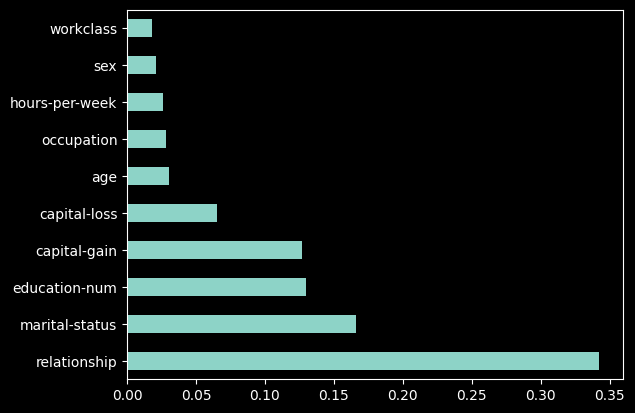

In [233]:
import matplotlib as plt

feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')

In [234]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [235]:
df_house.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [236]:
print(df_house.isna().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [237]:
df_house = df_house.select_dtypes(include=["int64", "float64"]).dropna()
print(df_house.isna().sum())

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64


In [238]:
X = df_house.drop("SalePrice", axis = 1)
y = df_house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

reg = xgb.XGBRegressor(n_estimators= 100, learning_rate= 0.1).fit(X_train, y_train)

pred = reg.predict(X_test)
print(f"R2 Score: {r2_score(y_test, pred):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, pred):.4f}")

R2 Score: 0.8980
MAE: $18053.7090


<Axes: >

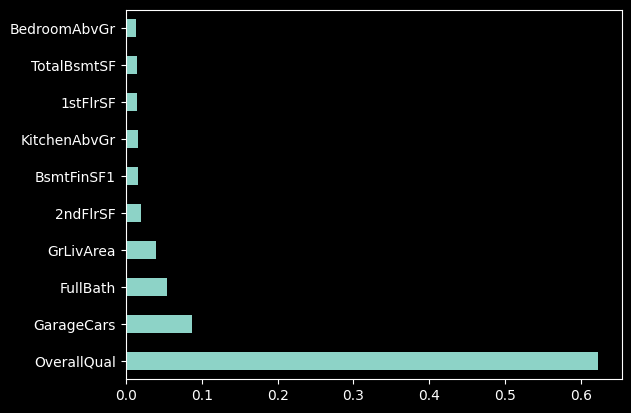

In [239]:
feat_importances = pd.Series(reg.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')